In [1]:
import torch

from notebooks.visualisation import plot_latent_comparison, plot_latent_comparison_multiclass
from utils.checkpoints import load_ae_from_path, load_cspn_from_path
from visualisation import show
from pathlib import Path
from checkpoints import load_from_wandb


In [2]:
ae_path = Path("../checkpoints/autoencoder/flowers.pt")
ae = load_ae_from_path(ae_path)

In [3]:
cspn_spf_path = Path("../checkpoints/cspn/flowers_spflow.pt")
cspn_spf = load_cspn_from_path(cspn_spf_path)

In [4]:
cspn_custom_path = Path("../checkpoints/cspn/flowers_custom.pt")
cspn_custom = load_cspn_from_path(cspn_custom_path)


In [5]:
cspn_psi_path = load_from_wandb("CSPN_flowers102_psinet", "", "flowers_custom.pt")
cspn_psi = load_cspn_from_path(cspn_psi_path, device=torch.device("cpu"))

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/jakob/.netrc.
wandb: Downloading large artifact 'CSPN_flowers102_psinet:latest', 60.30MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.4 (136.8MB/s)


{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


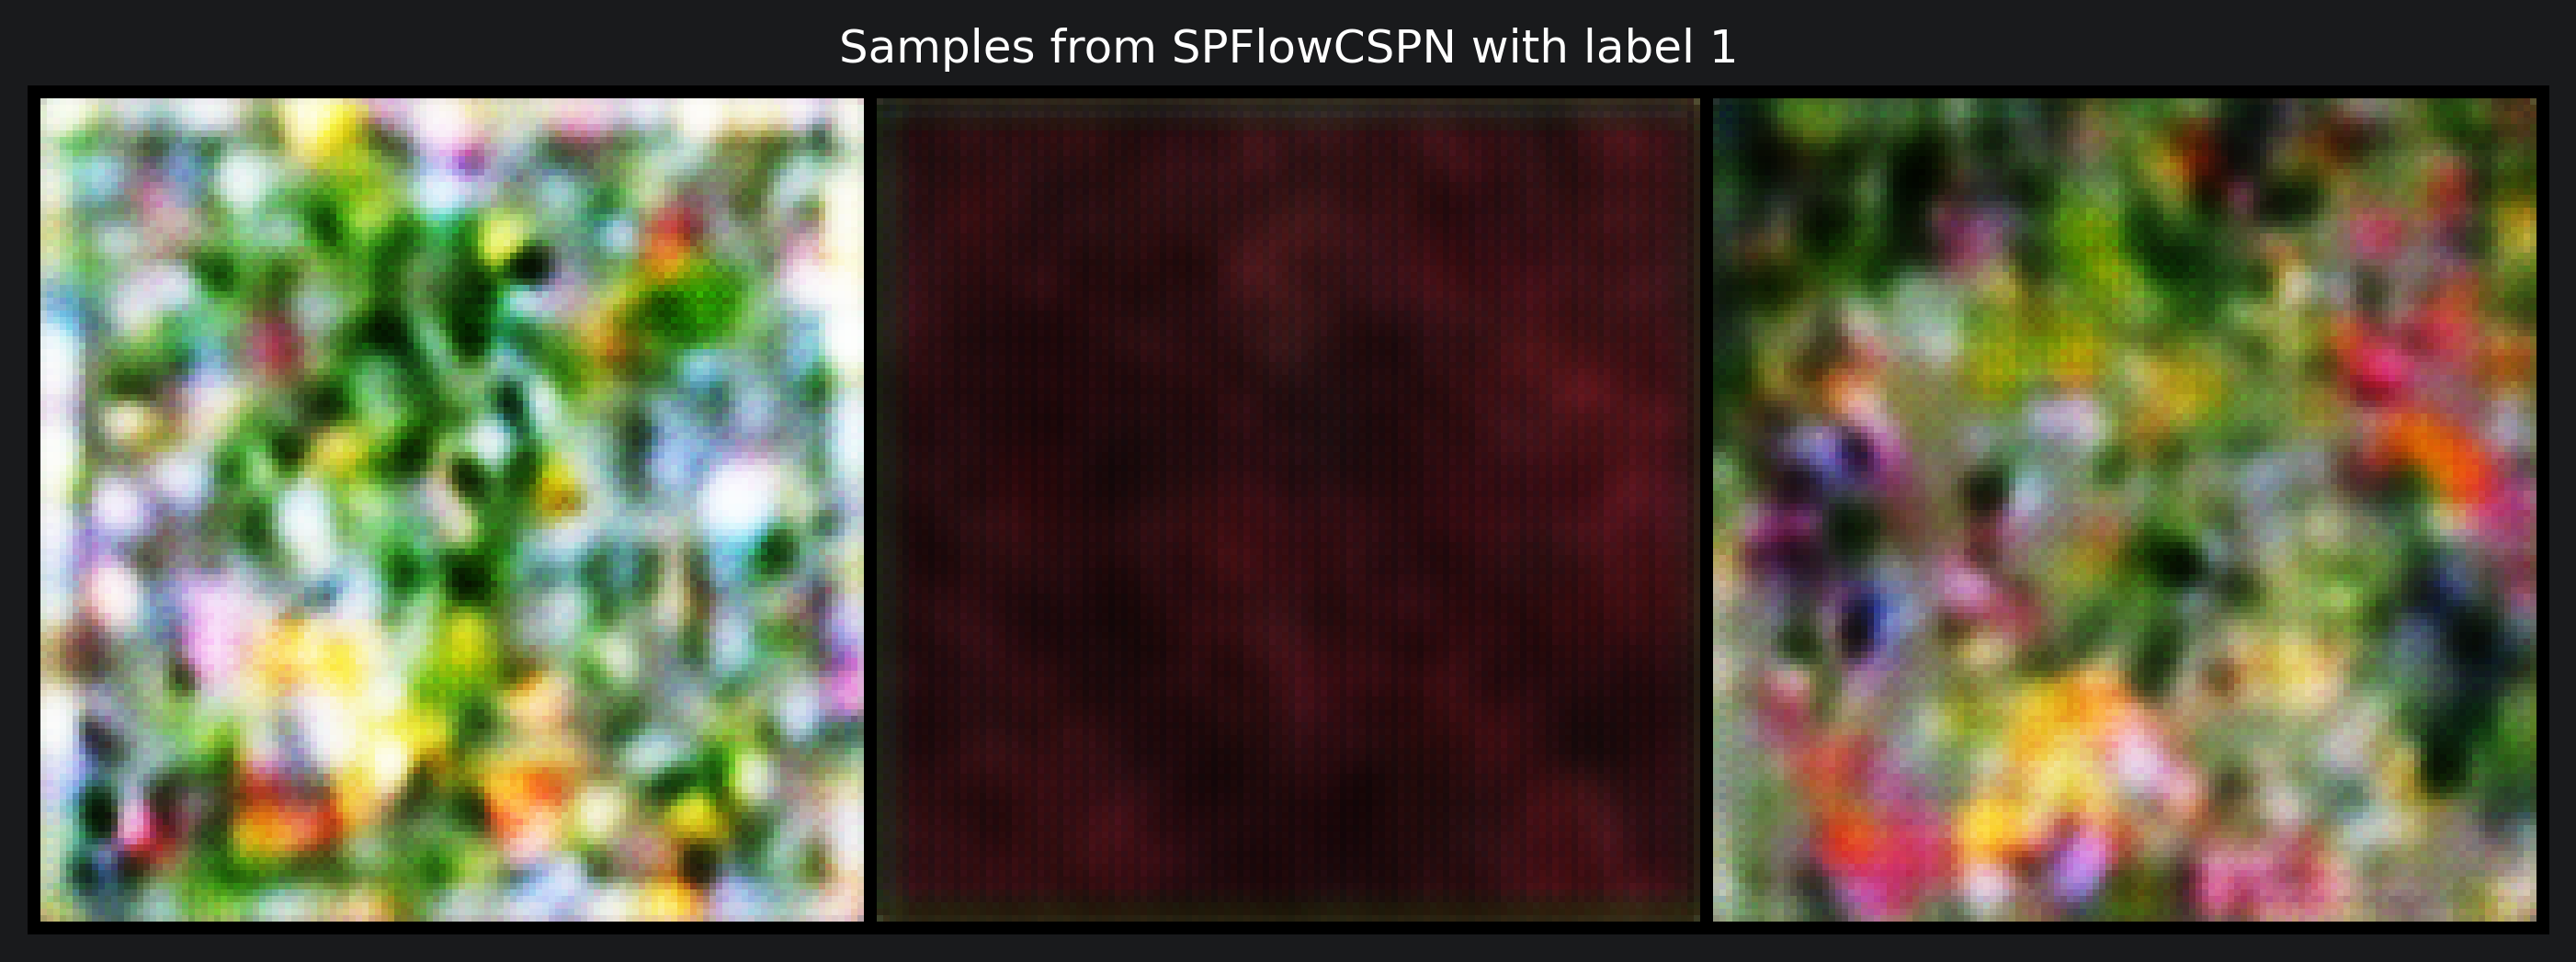

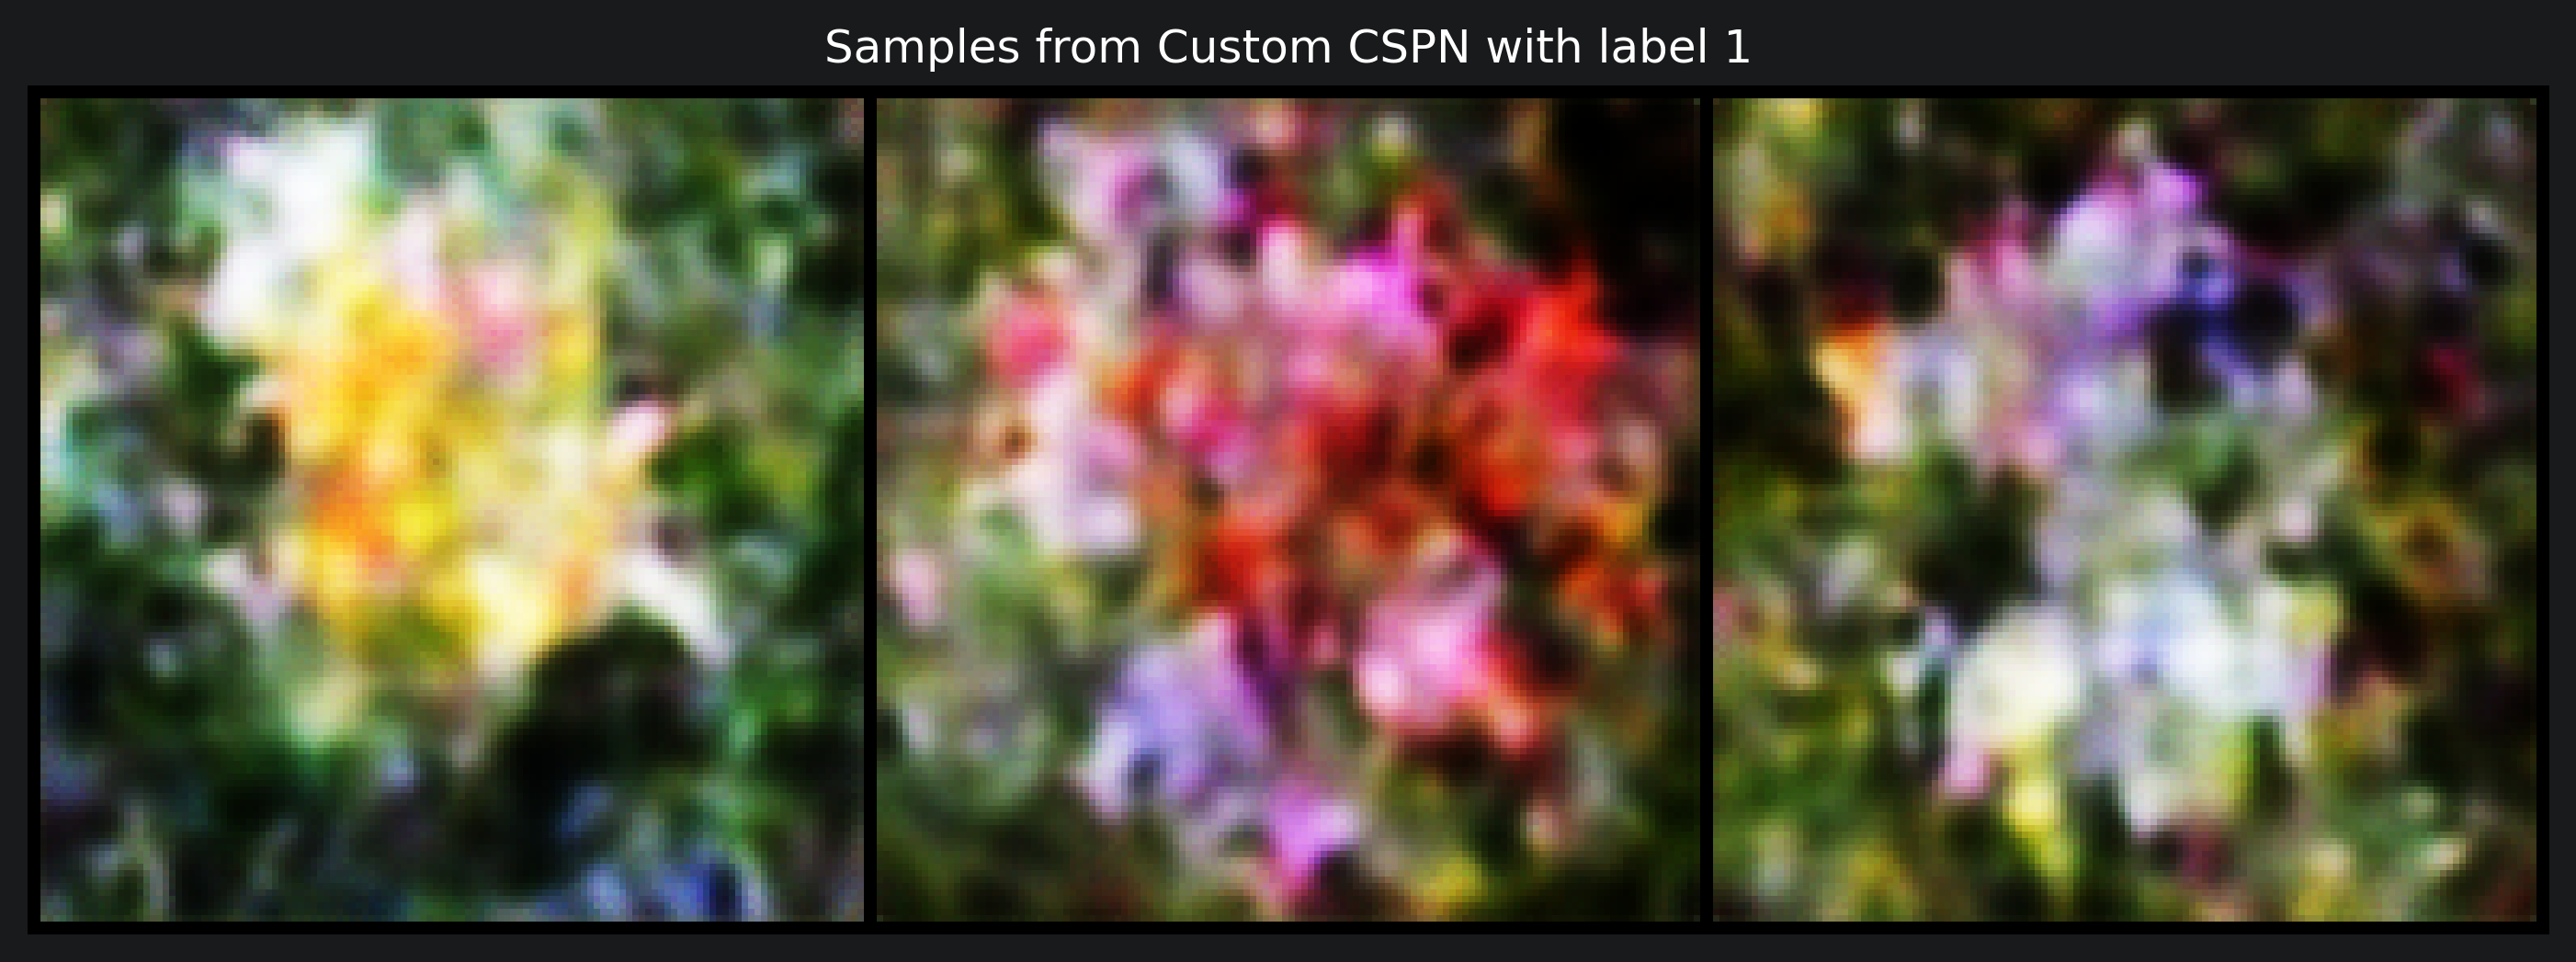

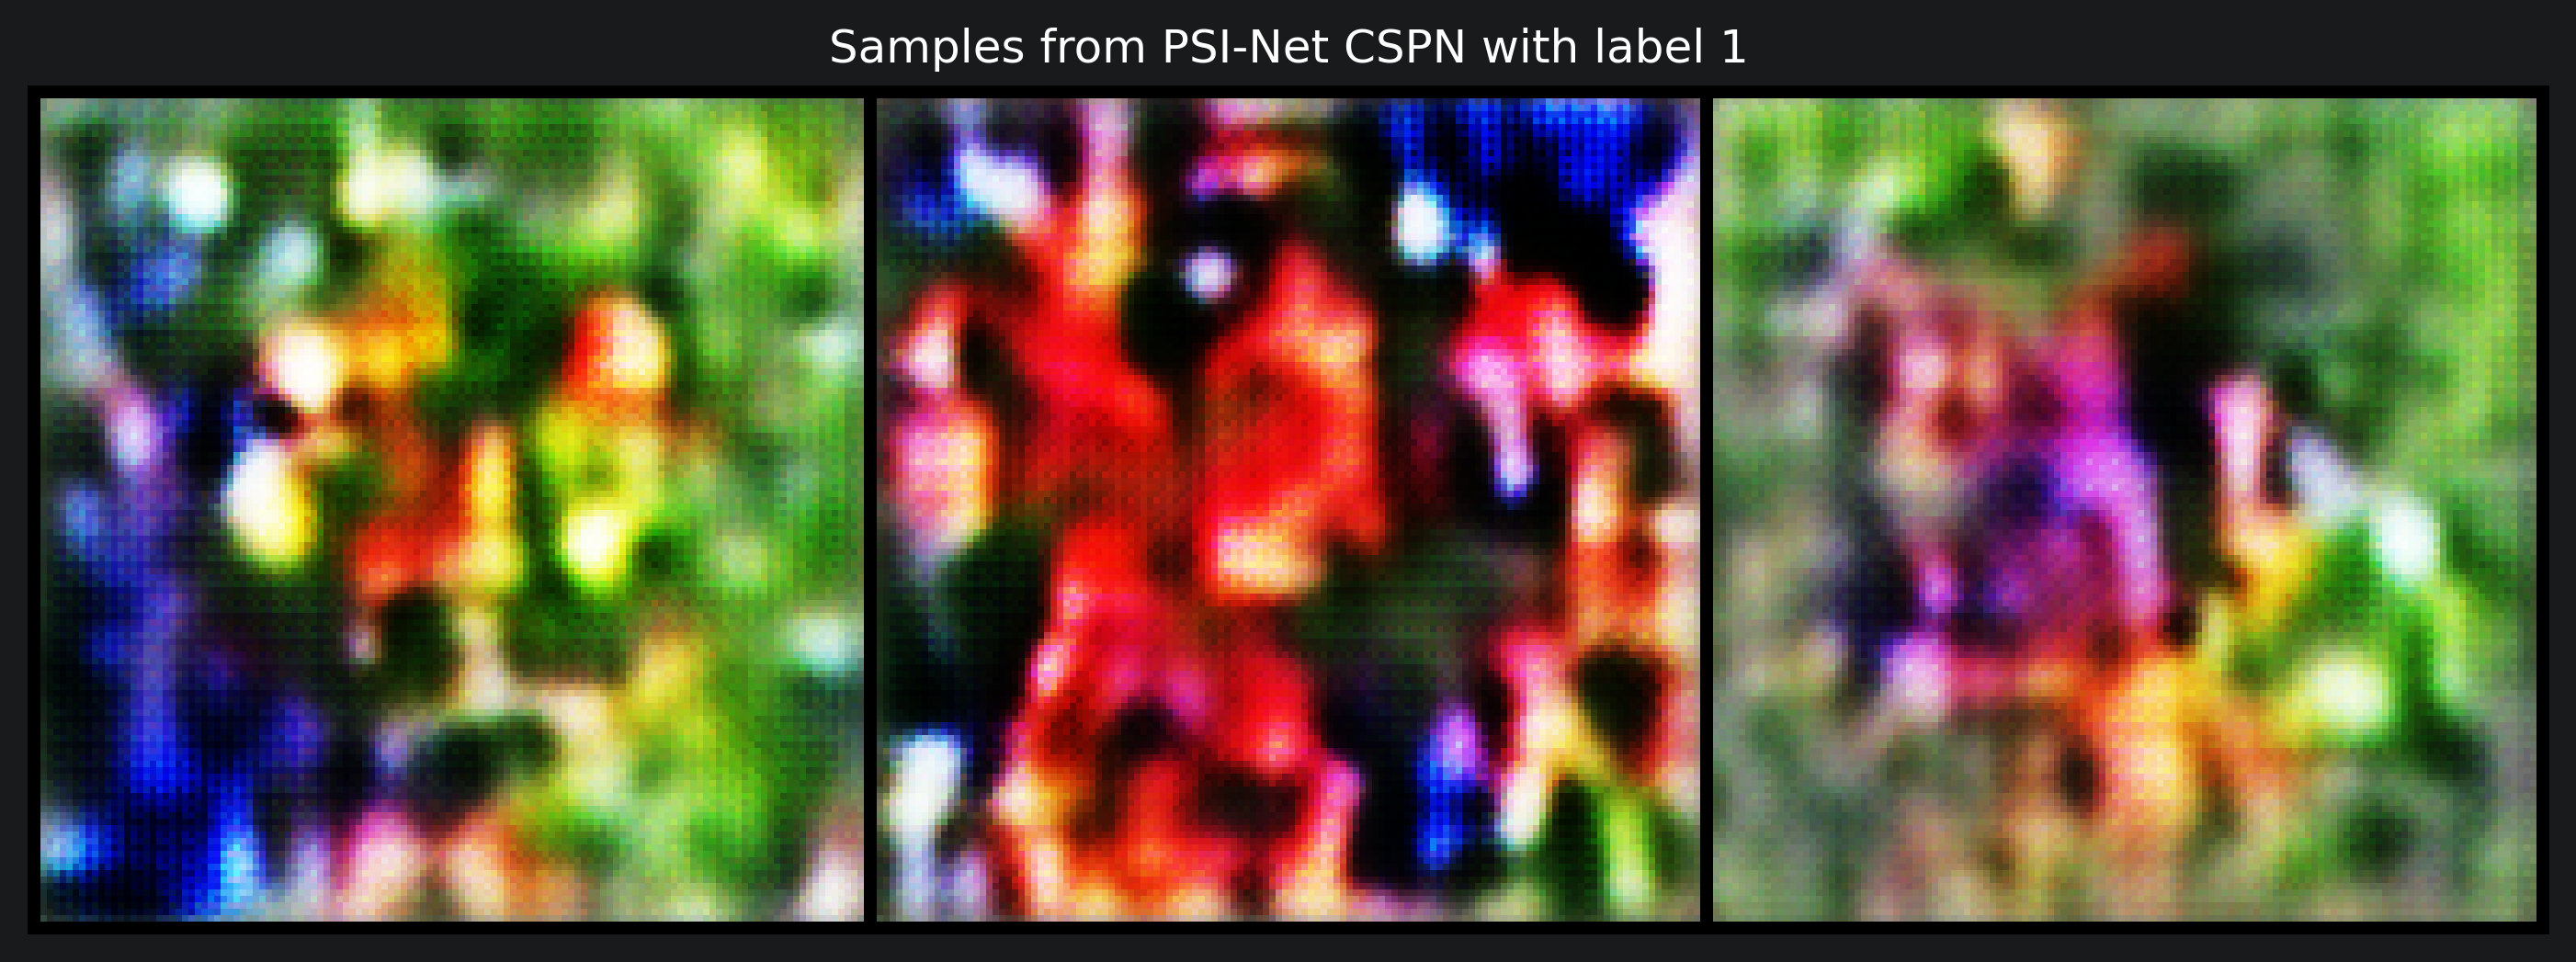

In [6]:
label = 1
sample_labels = torch.tensor([label] * 3)

with torch.no_grad():
    samples_spf = cspn_spf.sample(sample_labels)
    sampled_images_spf = ae.decode(samples_spf)
    samples_custom = cspn_custom.sample(sample_labels)
    sampled_images_custom = ae.decode(samples_custom)
    samples_psi = cspn_psi.sample(sample_labels)
    sampled_images_psi = ae.decode(samples_psi)

show(sampled_images_spf, f"Samples from SPFlowCSPN with label {label}")
show(sampled_images_custom, f"Samples from Custom CSPN with label {label}")
show(sampled_images_psi, f"Samples from PSI-Net CSPN with label {label}")

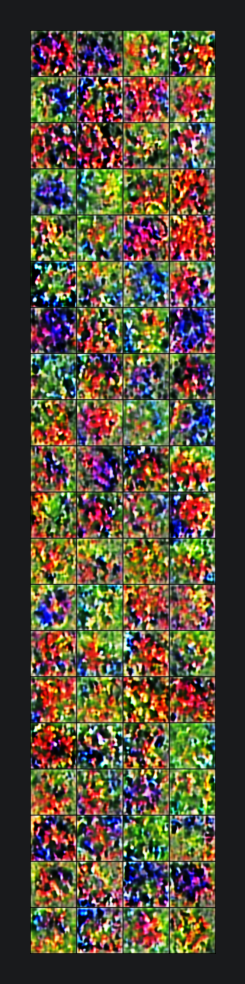

In [7]:
all_labels = torch.arange(40, 60).repeat_interleave(4)

with torch.no_grad():
    samples = cspn_psi.sample(all_labels)
    sampled_images = ae.decode(samples)

show(sampled_images, width=4)

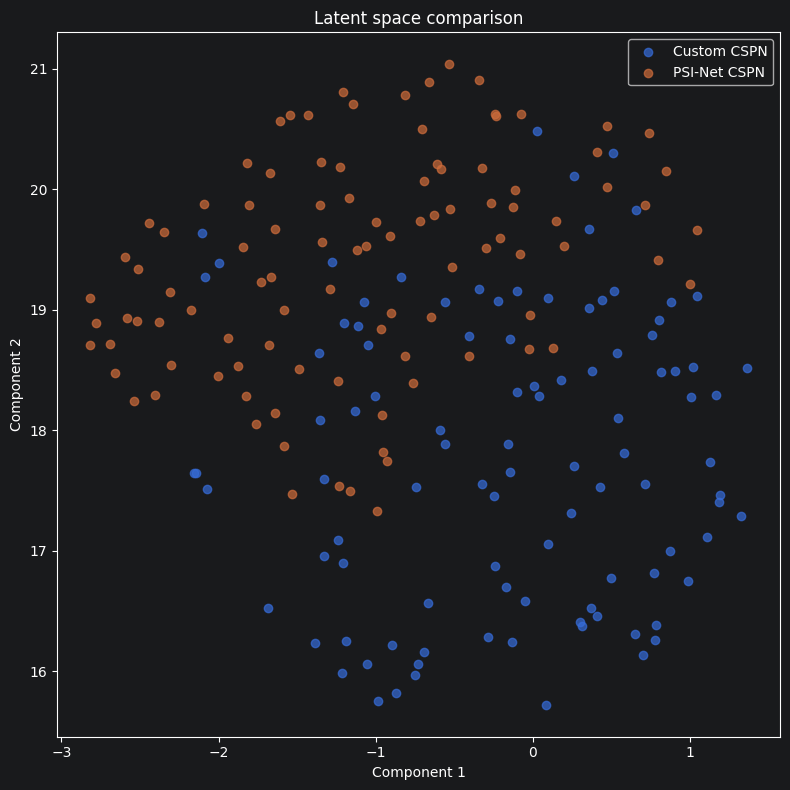

In [8]:
sample_labels_2 = torch.tensor([1] * 100)
with torch.no_grad():
    samples_custom = cspn_custom.sample(sample_labels_2)
    samples_psi = cspn_psi.sample(sample_labels_2)

plot_latent_comparison(samples_custom, samples_psi, name_a="Custom CSPN", name_b="PSI-Net CSPN")

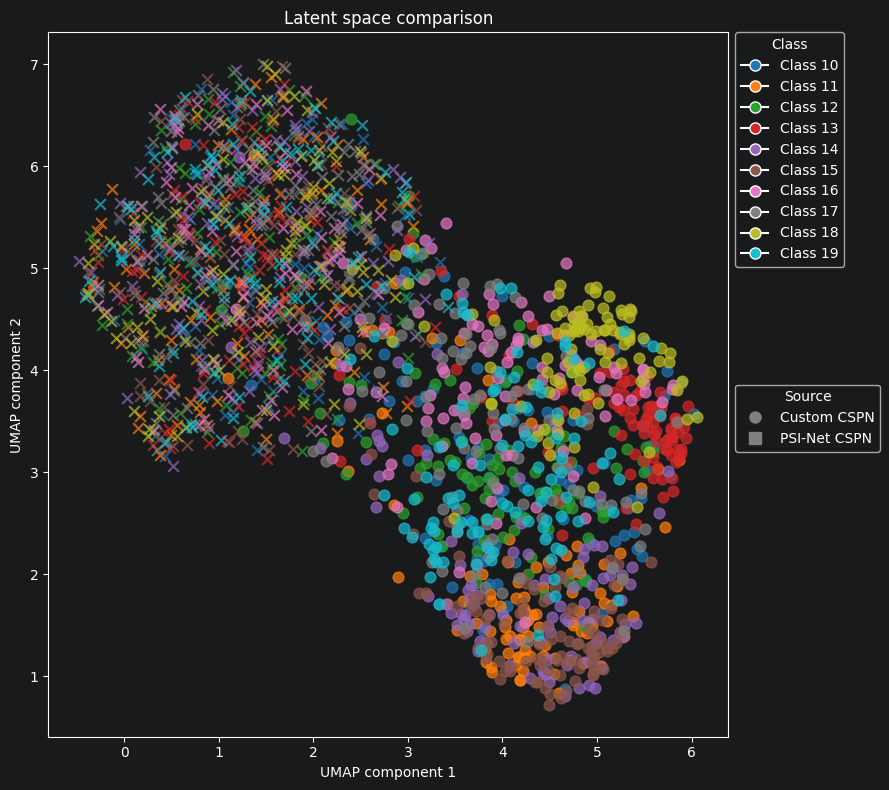

In [11]:
sample_multi_labels = torch.arange(10, 20).repeat_interleave(100)
with torch.no_grad():
    samples_custom = cspn_custom.sample(sample_multi_labels)
    samples_psi = cspn_psi.sample(sample_multi_labels)

plot_latent_comparison_multiclass(samples_custom, sample_multi_labels, samples_psi, sample_multi_labels,
                                  name_a="Custom CSPN", name_b="PSI-Net CSPN")